<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install pandas 
!pip install matplotlib 

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


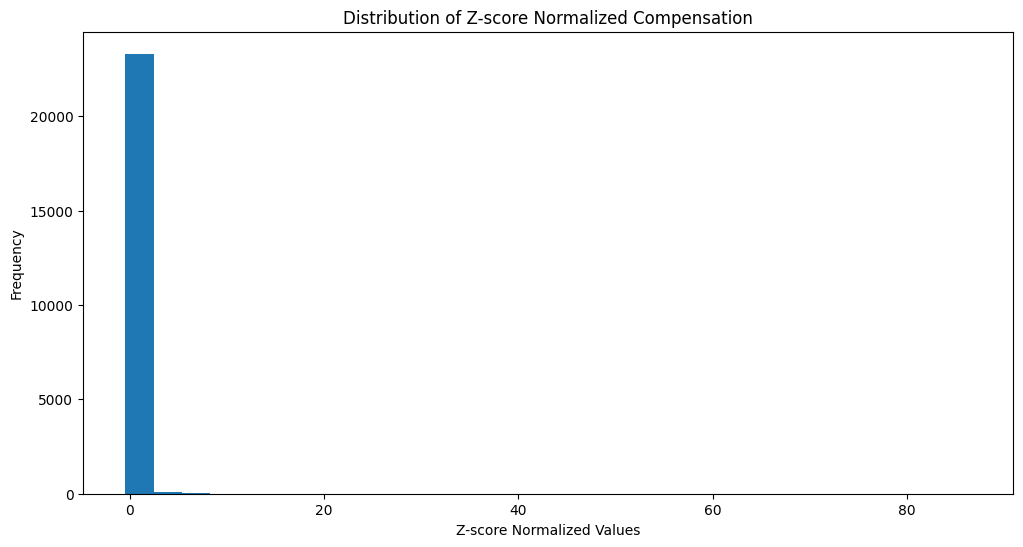

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

mean_salary = df_clean['ConvertedCompYearly'].mean()
std_salary = df_clean['ConvertedCompYearly'].std()

df_clean['Zscore_Compensation'] = (
    (df_clean['ConvertedCompYearly'] - mean_salary)
    / std_salary
)

plt.figure(figsize=(12,6))

plt.hist(df_clean['Zscore_Compensation'], bins=30)

plt.title("Distribution of Z-score Normalized Compensation")
plt.xlabel("Z-score Normalized Values")
plt.ylabel("Frequency")

plt.show()

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [4]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(url)

summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum()
})

print("Dataset Summary:\n")
print(summary)

Dataset Summary:

                    Data Type  Non-Null Count  Missing Values
ResponseId              int64           65447               0
MainBranch                str           65447               0
Age                       str           65447               0
Employment                str           65447               0
RemoteWork                str           54812           10635
...                       ...             ...             ...
JobSatPoints_11       float64           29446           36001
SurveyLength              str           56190            9257
SurveyEase                str           56246            9201
ConvertedCompYearly   float64           23435           42012
JobSat                float64           29126           36321

[114 rows x 3 columns]


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [5]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(url)

statistics = df.describe()

print("Basic Statistics for Numerical Columns:\n")
print(statistics)

Basic Statistics for Numerical Columns:

         ResponseId      CompTotal  ...  ConvertedCompYearly        JobSat
count  65447.000000   3.374000e+04  ...         2.343500e+04  29126.000000
mean   32714.001528  2.963841e+145  ...         8.615529e+04      6.935041
std    18893.063225  5.444117e+147  ...         1.867570e+05      2.088259
min        1.000000   0.000000e+00  ...         1.000000e+00      0.000000
25%    16352.500000   6.000000e+04  ...         3.271200e+04      6.000000
50%    32714.000000   1.100000e+05  ...         6.500000e+04      7.000000
75%    49075.500000   2.500000e+05  ...         1.079715e+05      8.000000
max    65437.000000  1.000000e+150  ...         1.625660e+07     10.000000

[8 rows x 14 columns]


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [6]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df['Country_clean'] = df['Country'].astype(str).str.strip()

country_counts = df['Country_clean'].value_counts()

inconsistent_countries = country_counts[country_counts < 5]

print("All Country Value Counts:\n")
print(country_counts)

print("\nPotential Inconsistent / Irrelevant Country Entries:\n")
print(inconsistent_countries)

All Country Value Counts:

Country_clean
United States of America                                11098
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3227
Ukraine                                                  2672
                                                        ...  
Haiti                                                       1
Nauru                                                       1
Chad                                                        1
Djibouti                                                    1
Solomon Islands                                             1
Name: count, Length: 185, dtype: int64

Potential Inconsistent / Irrelevant Country Entries:

Country_clean
Liechtenstein                            4
Fiji                                     4
Gabon                                    4
Bahamas                                 

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [7]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df['Country'] = df['Country'].astype(str).str.strip()

country_map = {
    "United States": "USA",
    "United States of America": "USA",
    "U.S.A.": "USA",
    "US": "USA",
    "India ": "India",
    "UK": "United Kingdom",
    "U.K.": "United Kingdom"
}

df['Country'] = df['Country'].replace(country_map)

df['EdLevel'] = df['EdLevel'].astype(str).str.strip()

edlevel_map = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor’s",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master’s",
    "Professional degree (JD, MD, etc.)": "Professional",
    "Associate degree": "Associate",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule)": "Secondary"
}

df['EdLevel'] = df['EdLevel'].replace(edlevel_map)

print("Standardized Country Values:\n")
print(df['Country'].value_counts().head(10))

print("\nStandardized Education Levels:\n")
print(df['EdLevel'].value_counts().head(10))

Standardized Country Values:

Country
USA                                                     11098
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3227
Ukraine                                                  2672
France                                                   2110
Canada                                                   2105
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Name: count, dtype: int64

Standardized Education Levels:

EdLevel
Bachelor’s                                                                            24943
Master’s                                                                              15559
Some College                                                                           7652

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [8]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])

df_encoded = pd.get_dummies(df, columns=['Employment'])

print("Encoded Dataset Columns:\n")
print(df_encoded.columns)

print("\nSample Encoded Data:\n")
print(df_encoded.head())

Encoded Dataset Columns:

Index(['ResponseId', 'MainBranch', 'Age', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'TechDoc',
       ...
       'Employment_Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time',
       'Employment_Student, full-time;Not employed, but looking for work;Retired',
       'Employment_Student, full-time;Not employed, but looking for work;Student, part-time',
       'Employment_Student, full-time;Retired',
       'Employment_Student, full-time;Student, part-time',
       'Employment_Student, full-time;Student, part-time;Employed, part-time',
       'Employment_Student, full-time;Student, part-time;Retired',
       'Employment_Student, part-time',
       'Employment_Student, part-time;Employed, part-time',
       'Employment_Student, part-time;Retired'],
      dtype='str', length=223)

Sample Encoded Data:

   ResponseId  ... Employment_Student, part-

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [9]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

missing_counts = df.isnull().sum()

missing_sorted = missing_counts.sort_values(ascending=False)

print("Columns sorted by missing values (highest first):\n")
print(missing_sorted[missing_sorted > 0])

print("\nTop 5 columns with highest missing values:\n")
print(missing_sorted.head(5))

Columns sorted by missing values (highest first):

AINextMuch less integrated    64299
AINextLess integrated         63092
AINextNo change               52947
AINextMuch more integrated    52008
EmbeddedAdmired               48711
                              ...  
YearsCode                      5569
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64

Top 5 columns with highest missing values:

AINextMuch less integrated    64299
AINextLess integrated         63092
AINextNo change               52947
AINextMuch more integrated    52008
EmbeddedAdmired               48711
dtype: int64


<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [10]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    if col == 'ConvertedCompYearly':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mean())

print("Missing values after imputation:\n")
print(df[num_cols].isnull().sum())

Missing values after imputation:

ResponseId             0
CompTotal              0
WorkExp                0
JobSatPoints_1         0
JobSatPoints_4         0
JobSatPoints_5         0
JobSatPoints_6         0
JobSatPoints_7         0
JobSatPoints_8         0
JobSatPoints_9         0
JobSatPoints_10        0
JobSatPoints_11        0
ConvertedCompYearly    0
JobSat                 0
dtype: int64


<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [12]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:\n")
print(df[cat_cols].isnull().sum())

Missing values after imputation:

MainBranch              0
Age                     0
Employment              0
RemoteWork              0
Check                   0
                       ..
ProfessionalCloud       0
ProfessionalQuestion    0
Industry                0
SurveyLength            0
SurveyEase              0
Length: 100, dtype: int64


### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [13]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

min_val = df_clean['ConvertedCompYearly'].min()
max_val = df_clean['ConvertedCompYearly'].max()

df_clean['ConvertedCompYearly_MinMax'] = (
    (df_clean['ConvertedCompYearly'] - min_val) /
    (max_val - min_val)
)

print("Original vs Normalized values:\n")
print(df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head(10))

Original vs Normalized values:

     ConvertedCompYearly  ConvertedCompYearly_MinMax
72                7322.0                    0.000450
374              30074.0                    0.001850
379              91295.0                    0.005616
385              53703.0                    0.003303
389             110000.0                    0.006766
392             161044.0                    0.009906
395             121018.0                    0.007444
398             195000.0                    0.011995
403              44586.0                    0.002743
409              57999.0                    0.003568


<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [14]:
import pandas as pd
import numpy as np

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

df_clean['ConvertedCompYearly_Log'] = np.log1p(df_clean['ConvertedCompYearly'])


print("Original vs Log-Transformed Values:\n")
print(df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_Log']].head(10))

Original vs Log-Transformed Values:

     ConvertedCompYearly  ConvertedCompYearly_Log
72                7322.0                 8.898775
374              30074.0                10.311450
379              91295.0                11.421862
385              53703.0                10.891243
389             110000.0                11.608245
392             161044.0                11.989439
395             121018.0                11.703703
398             195000.0                12.180760
403              44586.0                10.705198
409              57999.0                10.968198


### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [1]:
import pandas as pd


url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

def experience_level(years):
    if pd.isna(years):
        return "Unknown"
    elif years < 5:
        return "Beginner"
    elif years < 10:
        return "Intermediate"
    else:
        return "Expert"

df["ExperienceLevel"] = df["YearsCodePro"].apply(experience_level)

print(df[["YearsCodePro", "ExperienceLevel"]].head(10))

   YearsCodePro ExperienceLevel
0           NaN         Unknown
1          17.0          Expert
2          27.0          Expert
3           NaN         Unknown
4           NaN         Unknown
5           NaN         Unknown
6           7.0    Intermediate
7           NaN         Unknown
8           NaN         Unknown
9          11.0          Expert


### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
